In [1]:
import numpy as np 
# import image module
from IPython.display import Image
import matplotlib 
import matplotlib.pyplot as plt


# Simple implementation of LCG 


The generator is defined by the recurrence relation:

$X_{n+1}=\left(aX_{n}+b\right) \; {\text{mod} \; {m}}$


where $X$ is the sequence of pseudo-random values, and
$ m,\,0<m$  — the "modulus" (typically a prime number just less than a power of 2, i.e.,$2^{31}−1$ and $2^{61}−1$)
$ a,\,0<a<m$ — the "multiplier"
$ b,\,0\leq b<m$ — the "increment"
$X_{0},\,0\leq X_{0}<m$ — the "seed" or "start value". See wikipedia on LCG for common parameter choices (https://en.wikipedia.org/wiki/Linear_congruential_generator). 

Note: LCG algorithm does not work with a seed of zero.


In [7]:
def lcg(x, a, b, m):
    """
    Linear Congruential Generator (LCG) for pseudo-random number generation.

    This generator yields an infinite sequence of pseudo-random numbers using the
    linear congruential method defined by the recurrence relation:
        x_{n+1} = (a * x_n + b) % m

    Parameters
    ----------
    x : int
        Initial seed value.
    a : int
        Multiplier coefficient.
    b : int
        Increment value.
    m : int
        Modulus value.

    Yields
    ------
    int
        Next pseudo-random number in the sequence.
    """
    while True:
        x = (a * x + b) % m
        yield x

def random_uniform_sample(n, interval, seed=42):
    """
    Generate a list of uniformly distributed random integers within a specified interval.

    This function uses a linear congruential generator (LCG) with C++11 MINSTD parameters
    to produce pseudo-random numbers. Each number is scaled to the given interval and
    rounded to the nearest integer.

    Parameters
    ----------
    n : int
        Number of random samples to generate.
    interval : tuple of float
        A tuple (lower, upper) specifying the range from which to sample.
    seed : int, optional
        Seed value for the LCG. Default is 42.

    Returns
    -------
    list of int
        A list containing `n` uniformly distributed random integers within the specified interval.
    """
    # use C++11 MINSTD values 
    m = 2**(31)-1
    a = 43271
    b = 0
    
    bsdrand = lcg(seed, a, b, m)
    
    lower, upper = interval[0], interval[1]
    sample = []

    for i in range(n):
        observation = (upper - lower) * (next(bsdrand) / (m - 1)) + lower
        sample.append(round(observation))

    return sample

In [8]:
random_sequence_1 = random_uniform_sample(30,[0,10])
print(random_sequence_1)

[0, 6, 6, 4, 4, 2, 10, 2, 0, 5, 1, 6, 7, 3, 4, 3, 5, 8, 2, 4, 4, 5, 3, 6, 0, 8, 6, 7, 4, 9]


These random numbers are ONLY **pseudo**random: 

In [12]:
random_sequence_2 = random_uniform_sample(30,[0,10],seed=42)
print(random_sequence_1)
print(random_sequence_2)

[0, 6, 6, 4, 4, 2, 10, 2, 0, 5, 1, 6, 7, 3, 4, 3, 5, 8, 2, 4, 4, 5, 3, 6, 0, 8, 6, 7, 4, 9]
[0, 6, 6, 4, 4, 2, 10, 2, 0, 5, 1, 6, 7, 3, 4, 3, 5, 8, 2, 4, 4, 5, 3, 6, 0, 8, 6, 7, 4, 9]


# Numpy Random Number Generator: PCG64 

Numpy uses a permutated congrential generator (see here: https://numpy.org/doc/stable/reference/random/generator.html), which applies an output permutation function to improve the statistical properties of a modulo-2n linear congruential generator (LCG) (as implemented above).

A PCG is very similar to an LCG - it is still based on a recurrence relation of the form $X_{n+1}=\left(aX_{n}+b\right) \; {\text{mod} \; {m}}$.  A PCG adds a permutation step to the LCG.

$ u = \left(a X_n + b\right) \;\text{mod}\; 2n$

$ X_{n+1} = u \oplus (u \gg p) $


where $u$ is a temporary variable, $𝑝$
 is a positive integer constant, $\oplus$
 denotes bitwise xor, and $\gg$
 denotes a bitwise right shift. See wikipedia (https://en.wikipedia.org/wiki/Permuted_congruential_generator) for more details. 

Numpy uses ["fresh, unpredictable entropy will be pulled from the OS."](https://numpy.org/doc/stable/reference/random/bit_generators/index.html#seeding-and-entropy) if no seed is given:

In [29]:
rng = np.random.default_rng()
rng.integers(low=0, high=10, size=30)  

array([6, 5, 8, 3, 9, 6, 6, 3, 6, 7, 7, 0, 0, 0, 1, 1, 8, 3, 1, 1, 2, 2,
       0, 7, 0, 9, 8, 7, 1, 3])

In [30]:
rng2 = np.random.default_rng()
rng2.integers(low=0, high=10, size=30)  

array([2, 9, 7, 9, 4, 9, 4, 8, 3, 1, 7, 4, 2, 4, 9, 0, 9, 7, 1, 2, 5, 4,
       3, 0, 3, 0, 3, 6, 0, 2])

In [33]:
rng1 = np.random.default_rng(seed=42)
output1 = rng1.integers(low=0, high=10, size=30)  
rng2 = np.random.default_rng(seed=42)
output2 = rng2.integers(low=0, high=10, size=30)  

print(output1) 
print(output2)

[0 7 6 4 4 8 0 6 2 0 5 9 7 7 7 7 5 1 8 4 5 3 1 9 7 6 4 8 5 4]
[0 7 6 4 4 8 0 6 2 0 5 9 7 7 7 7 5 1 8 4 5 3 1 9 7 6 4 8 5 4]


if you generate more random numbers, the seqeunce is continued:

In [36]:
rng2.integers(low=0, high=10, size=30)  

array([4, 8, 8, 3, 8, 2, 2, 6, 6, 1, 8, 1, 8, 0, 7, 7, 7, 6, 4, 7, 2, 7,
       5, 4, 5, 5, 0, 1, 2, 1])

# Floating point random numbers 

Generate integers, then rescale to get floats in desired range. 

In [43]:
def random_uniform_sample_float(n, interval, seed=42):
    RAND_MAX = 32767
    random_integers = random_uniform_sample(n,[0,RAND_MAX])
    random_integers = np.asarray(random_integers)/RAND_MAX
    random_floats = interval[0] + random_integers*(interval[1]-interval[0])
    return random_floats

In [44]:
random_sequence_1 = random_uniform_sample_float(30,[0,10.0])
print(random_sequence_1)


[8.54518265e-03 6.19586779e+00 5.90533158e+00 4.48622089e+00
 4.08093509e+00 1.76213874e+00 9.90630818e+00 1.50364696e+00
 2.33161412e-01 4.69100009e+00 1.04495376e+00 6.30726035e+00
 7.06564531e+00 3.12417982e+00 3.57860042e+00 2.93252358e+00
 4.79476302e+00 7.79290139e+00 2.02063051e+00 4.19232765e+00
 3.71440779e+00 5.28397473e+00 3.18216498e+00 6.08050783e+00
 1.40995514e-01 7.65495773e+00 5.53270058e+00 7.48069704e+00
 3.78612629e+00 9.47569201e+00]


# Gaussian random Numbers 

So far, all random numbers we generated were **uniformly** distributed. What if we want to generate numbers from a different probability distribution, like a Gaussian distribution? For this we can use transformations, e.g. the [Box-Muller transform](https://en.wikipedia.org/wiki/Box%E2%80%93Muller_transform).

For this we need the gaussian integral: 

$\int_{-\infty}^\infty e^{-x^2/2} dx = \sqrt{2\pi}$ 

we will not do the derivation here. 

Let's say we want create two sets of random numbers ($X$ and $Y$), each with a probability density function given by a Gaussian integral ($p(X)$ and $p(Y)$). We can use the result above to get expressions for $p(X)$ and $p(Y)$:

\begin{align}
p(X) = \frac{1}{\sqrt{2\pi}} e^{- X^2 /2 }\\
p(Y) = \frac{1}{\sqrt{2\pi}} e^{- Y^2 /2 }
\end{align}

We can call the total probability density function $p(X,Y)$. (This is a 2D Gaussian) Since $X$ and $Y$ are independent sets of numbers:

\begin{align}
p(X,Y) &= p(X)p(Y)\\[0.1cm]
&= \left [ \frac{1}{\sqrt{2\pi}} e^{- X^2 /2 } \right ] \left [ \frac{1}{\sqrt{2\pi}} e^{- Y^2 /2 } \right ]\\[0.1cm]
&= \frac{1}{2\pi} e^{- (X^2+Y^2) /2 }
\end{align}

Let's define $R^2 = X^2 + Y^2$ (effectively transforming into polar coordinates): 

$p(X,Y) \Rightarrow p(R,\Theta) = \frac{1}{2\pi} e^{- R^2 /2 }$

Suppose we can generate two uniformly distributed sets of numbers between zero and one, not including zero. Call them $U_1$
 and $U_2$. First, we can transform $U_1$
 and $U_2$ into two new sets, $\Theta$ and $R$
 based on the expression above:

\begin{align}
U_1 &= \frac{\Theta}{2\pi} \Rightarrow &\Theta &= 2\pi U_1\\
U_2 &= e^{-R^2/2} \Rightarrow &R &= \sqrt{-2\ln(U_2)}
\end{align}

The first expression for $\Theta$
 represents a uniform distribution of numbers over all values from zero to $2\pi$
 (i.e. over all angles). The second expression for $R$
 represents a Gaussian distribution. We can now convert these polar coordinates to cartesian coordinates using $X=R\cos(\Theta)$
, and $Y=R\sin(\Theta)$
:

\begin{align}
X = R\cos(\Theta) = \sqrt{-2\ln(U_2)} \cos(2\pi U_1)\\
Y = R\sin(\Theta) = \sqrt{-2\ln(U_2)} \sin(2\pi U_1)
\end{align}

$X$ and $Y$ both have Gaussian distributions because $R$ and $Θ$ had Gaussian distributions!

In [13]:
Image(url="https://upload.wikimedia.org/wikipedia/commons/1/1f/Box-Muller_transform_visualisation.svg", width=400, height=400)

Visualization from Wikipedia, by <a href="//commons.wikimedia.org/wiki/User:Cmglee" title="User:Cmglee">Cmglee</a> - <span class="int-own-work" lang="en">Own work</span>, <a href="https://creativecommons.org/licenses/by-sa/3.0" title="Creative Commons Attribution-Share Alike 3.0">CC BY-SA 3.0</a>, <a href="https://commons.wikimedia.org/w/index.php?curid=36927961">Link</a>

In [14]:
num_pairs = 1000
u1 = np.random.uniform(0, 1, num_pairs)
u2 = np.random.uniform(0, 1, num_pairs)

# Apply the Box-Muller transform equations
z1 = np.sqrt(-2 * np.log(u2)) * np.cos(2 * np.pi * u1)
z2 = np.sqrt(-2 * np.log(u2)) * np.sin(2 * np.pi * u1)

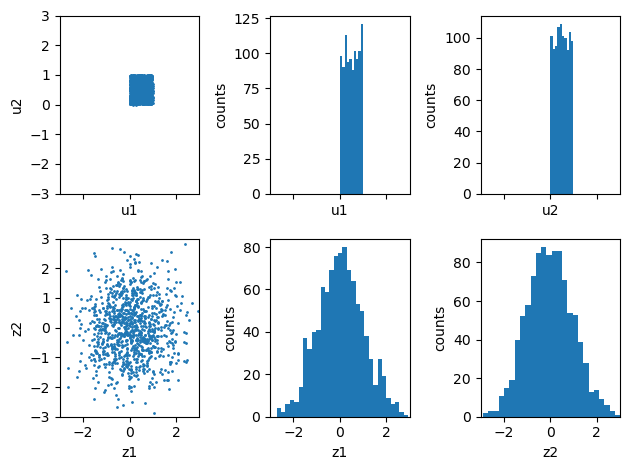

In [72]:
fig, ax = plt.subplots(2,3,sharex=True)

ax[0,0].scatter(u1,u2,s=1) 
ax[1,0].scatter(z1,z2,s=1)

ax[0,1].hist(u1)
ax[0,2].hist(u2)

ax[1,1].hist(z1,bins=30)
ax[1,2].hist(z2,bins=30)

ax[0,0].set_ylim(-3,3)
ax[0,0].set_xlim(-3,3)

ax[0,0].set_xlabel('u1')
ax[0,0].set_ylabel('u2')

ax[0,1].set_xlabel('u1')
ax[0,2].set_xlabel('u2')
ax[0,1].set_ylabel('counts')
ax[0,2].set_ylabel('counts')

ax[1,0].set_ylim(-3,3)
ax[1,0].set_xlim(-3,3)

ax[1,0].set_xlabel('z1')
ax[1,0].set_ylabel('z2')

ax[1,1].set_xlabel('z1')
ax[1,2].set_xlabel('z2')
ax[1,1].set_ylabel('counts')
ax[1,2].set_ylabel('counts')
plt.tight_layout()
plt.show()